# Impact surface and residual-alpha screen

This notebook separates two questions:

1. Can contemporaneous impact be represented by a transparent surface in relative imbalance and relative activity?
2. Once that surface is calibrated using past data only, do its residuals predict future returns?

The first question is market-impact modelling. The second is an alpha test. The power surface is the primary model; superseded log-activity results remain archived but are not part of the active comparison. June–August 2026 are absent from the feature cache and remain an untouched holdout. All figures below use compact result tables generated by `run_impact_surface_residual_alpha.py`, `run_rolling_power_surface.py`, and `run_power_surface_symmetry.py`; changing the controls does not refit or rescan the underlying bars.

## Definitions

$$
z=\frac{|Q^{signed}|}{Q^{gross}},\qquad
a=\frac{Q^{gross}}{V_{24h}},\qquad
y=\frac{\operatorname{sign}(Q^{signed})r}{\sigma_{24h}}.
$$

The unrestricted power surface is

$$
\widehat I(z,a)=A z^p a^q.
$$

For that family only, the candidate collapsed variable is

$$
x^*=z a^\gamma,\qquad \gamma=q/p,
$$

so that $\widehat I=A(x^*)^p$. A successful algebraic rewrite is not evidence of scale collapse: $\gamma$ must also be stable and the activity-coloured cell curves must overlap out of sample.

In [1]:
from pathlib import Path
import json
import math
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
RESULTS = REPO / 'alpha-search' / 'reports' / 'impact_surface_residual_alpha_v1'
manifest = json.loads((RESULTS / 'run_manifest.json').read_text())
fits = pl.read_csv(RESULTS / 'surface_fits.csv')
surface_cells = pl.read_csv(RESULTS / 'surface_cells.csv')
residual_ic = pl.read_csv(RESULTS / 'residual_ic.csv')
residual_quantiles = pl.read_csv(RESULTS / 'residual_quantiles.csv')
residual_strategies = pl.read_csv(RESULTS / 'residual_strategies.csv')
horizon_accuracy = pl.read_csv(RESULTS / 'horizon_accuracy.csv')

ROLLING_RESULTS = REPO / 'alpha-search' / 'reports' / 'rolling_power_surface_v1'
rolling_manifest = json.loads((ROLLING_RESULTS / 'run_manifest.json').read_text())
rolling_fits = pl.read_csv(ROLLING_RESULTS / 'rolling_fits.csv')
rolling_calibration = pl.read_csv(ROLLING_RESULTS / 'rolling_calibration.csv')
cadence_summary = pl.read_csv(ROLLING_RESULTS / 'cadence_summary.csv')
symmetry = pl.read_csv(ROLLING_RESULTS / 'symmetry_comparison.csv')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})
BUY, SELL = '#13795b', '#c2413b'
MODEL_COLOURS = {
    'relative_imbalance_power': '#64748b',
    'normalised_flow_power': '#d97706',
    'normalised_flow_log': '#7c3aed',
    'surface_power': '#2563eb',
}

## Manual controls

In [2]:
CONSTRUCTION = 'event_200'       # event_200, event_500, event_1000, time_1m, time_2m, time_5m
FOLD = 3                         # 1..5; fold 3 tests calendar 2024
SIDE = 'buy'                     # buy or sell
MODEL = 'surface_power'          # choose from MODEL_COLOURS above
HORIZON_MINUTES = 15             # 5, 10, 15, or 30
ROLLING_WINDOW = '12m'           # 6m, 12m, 18m, 24m, 36m, or expanding
CALIBRATION_DATE_LABEL_EVERY = 6 # label every nth monthly calibration date
WINDOW_COMPARISON_START = '2022-10-01' # first origin with every history available

assert CONSTRUCTION in manifest['config']['constructions']
assert FOLD in {row['fold'] for row in manifest['config']['folds']}
assert SIDE in {'buy', 'sell'}
assert MODEL == 'surface_power'
assert HORIZON_MINUTES in manifest['config']['future_horizons_minutes']
assert ROLLING_WINDOW in {'6m', '12m', '18m', '24m', '36m', 'expanding'}
assert CALIBRATION_DATE_LABEL_EVERY >= 1
assert WINDOW_COMPARISON_START == rolling_manifest['config']['common_window_comparison_start']

fold_definition = next(row for row in manifest['config']['folds'] if row['fold'] == FOLD)
display(Markdown(
    f"**Selected experiment:** `{CONSTRUCTION}`, {SIDE}, fold {FOLD}. "
    f"Training ends before `{fold_definition['train_end']}`; testing is "
    f"`{fold_definition['test_start']}` to `{fold_definition['test_end']}`."
))

**Selected experiment:** `event_200`, buy, fold 3. Training ends before `2024-01-01`; testing is `2024-01-01` to `2025-01-01`.

## Fitted surface equation and chronology

In [3]:
selected_fit = fits.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE) &
    (pl.col('model') == MODEL)
).row(0, named=True)
display(pl.DataFrame([selected_fit]))

display(Markdown(
    rf"$$\widehat I={selected_fit['amplitude']:.5g}"
    rf"z^{{{selected_fit['imbalance_exponent_p']:.3f}}}"
    rf"a^{{{selected_fit['activity_exponent_q']:.3f}}},\qquad "
    rf"x^*=za^{{{selected_fit['collapse_exponent_gamma']:.3f}}}.$$"
))

display(horizon_accuracy.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('fold') == FOLD)
).sort('horizon_minutes'))

construction,fold,side,model,train_observations,test_observations,training_cells,amplitude,imbalance_exponent_p,activity_exponent_q,collapse_exponent_gamma,imbalance_scale,curvature,train_cell_rmse,test_cell_rmse,test_cells,test_bar_rmse,test_residual_log_activity_correlation
str,i64,str,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""event_200""",3,"""buy""","""surface_power""",3911012,954177,72,0.758458,0.87,0.43,0.494253,1.0,NaN,0.000342,0.001326,72,0.010698,-0.105415


$$\widehat I=0.75846z^{0.870}a^{0.430},\qquad x^*=za^{0.494}.$$

construction,fold,horizon_minutes,observations,elapsed_p10_minutes,elapsed_median_minutes,elapsed_p90_minutes
str,i64,i64,i64,f64,f64,f64
"""event_200""",3,5,1923979,5.014967,5.100783,5.3795
"""event_200""",3,10,1923979,10.015933,10.105317,10.388467
"""event_200""",3,15,1923979,15.016567,15.108133,15.392383
"""event_200""",3,30,1923979,30.01765,30.113883,30.402233


## The observed two-dimensional surface

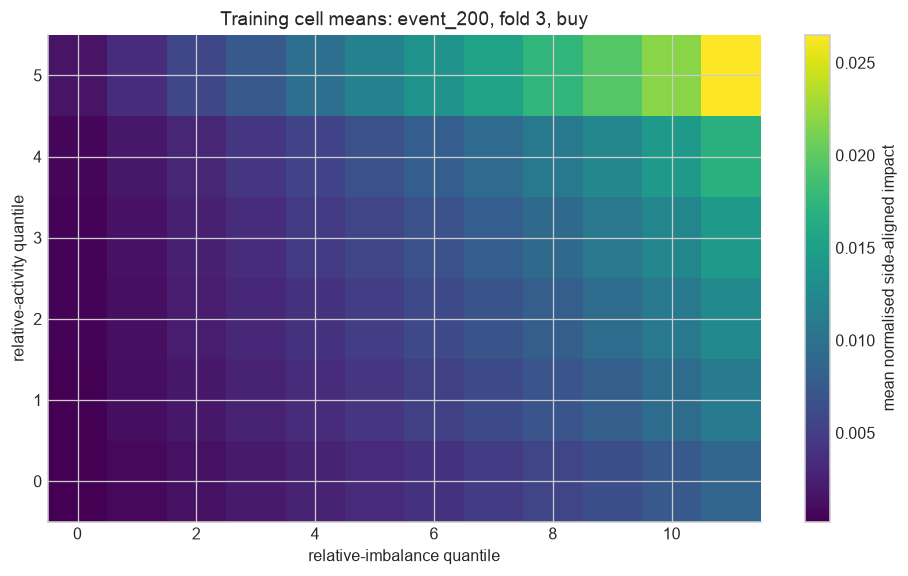

In [4]:
cells = surface_cells.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE)
).sort('activity_bin', 'imbalance_bin')
n_a = int(cells['activity_bin'].max())
n_z = int(cells['imbalance_bin'].max())
matrix = np.full((n_a, n_z), np.nan)
for row in cells.iter_rows(named=True):
    matrix[row['activity_bin'] - 1, row['imbalance_bin'] - 1] = row['mean_normalised_impact']

fig, ax = plt.subplots(figsize=(10, 5.5))
image = ax.imshow(matrix, origin='lower', aspect='auto', cmap='viridis')
ax.set_xlabel('relative-imbalance quantile')
ax.set_ylabel('relative-activity quantile')
ax.set_title(f'Training cell means: {CONSTRUCTION}, fold {FOLD}, {SIDE}')
fig.colorbar(image, ax=ax, label='mean normalised side-aligned impact')
plt.show()

## Activity slices before and after the proposed collapse

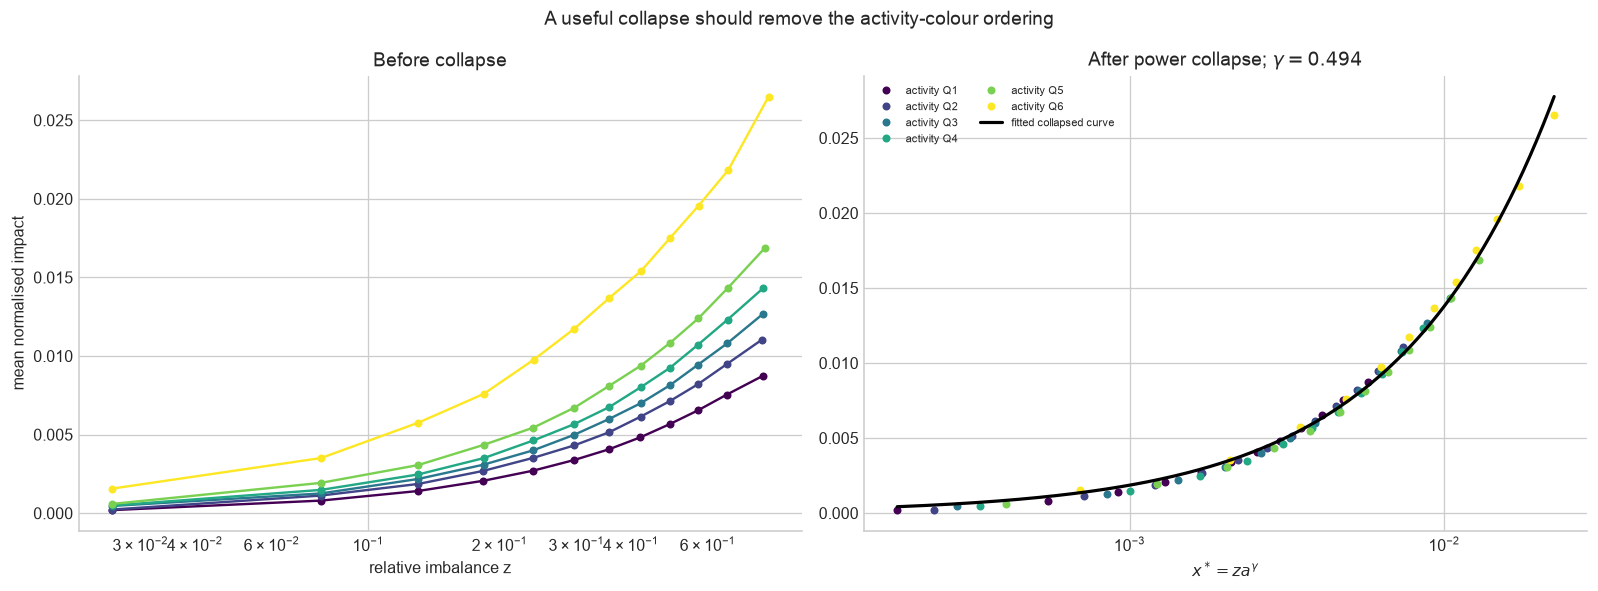

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
cmap = plt.get_cmap('viridis')
for activity_bin in sorted(cells['activity_bin'].unique()):
    part = cells.filter(pl.col('activity_bin') == activity_bin).sort('mean_relative_imbalance')
    colour = cmap((activity_bin - 1) / max(1, n_a - 1))
    axes[0].plot(part['mean_relative_imbalance'], part['mean_normalised_impact'],
                 'o-', ms=4, color=colour, label=f'activity Q{activity_bin}')
axes[0].set_xscale('log')
axes[0].set_xlabel('relative imbalance z')
axes[0].set_ylabel('mean normalised impact')
axes[0].set_title('Before collapse')

power_fit = fits.filter(
    (pl.col('construction') == CONSTRUCTION) & (pl.col('fold') == FOLD) &
    (pl.col('side') == SIDE) & (pl.col('model') == 'surface_power')
).row(0, named=True)
gamma = power_fit['collapse_exponent_gamma']
for activity_bin in sorted(cells['activity_bin'].unique()):
    part = cells.filter(pl.col('activity_bin') == activity_bin).with_columns(
        (pl.col('mean_relative_imbalance') *
         pl.col('mean_relative_activity').pow(gamma)).alias('x_star')
    ).sort('x_star')
    colour = cmap((activity_bin - 1) / max(1, n_a - 1))
    axes[1].plot(part['x_star'], part['mean_normalised_impact'],
                 'o', ms=4, color=colour, label=f'activity Q{activity_bin}')
all_x = cells.with_columns(
    (pl.col('mean_relative_imbalance') *
     pl.col('mean_relative_activity').pow(gamma)).alias('x_star')
)['x_star'].to_numpy()
grid = np.geomspace(all_x.min(), all_x.max(), 300)
axes[1].plot(grid, power_fit['amplitude'] * grid ** power_fit['imbalance_exponent_p'],
             color='black', lw=2, label='fitted collapsed curve')
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$x^*=za^\gamma$')
axes[1].set_title(rf'After power collapse; $\gamma={gamma:.3f}$')
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle('A useful collapse should remove the activity-colour ordering')
plt.tight_layout()
plt.show()

## Is the collapse exponent stable?

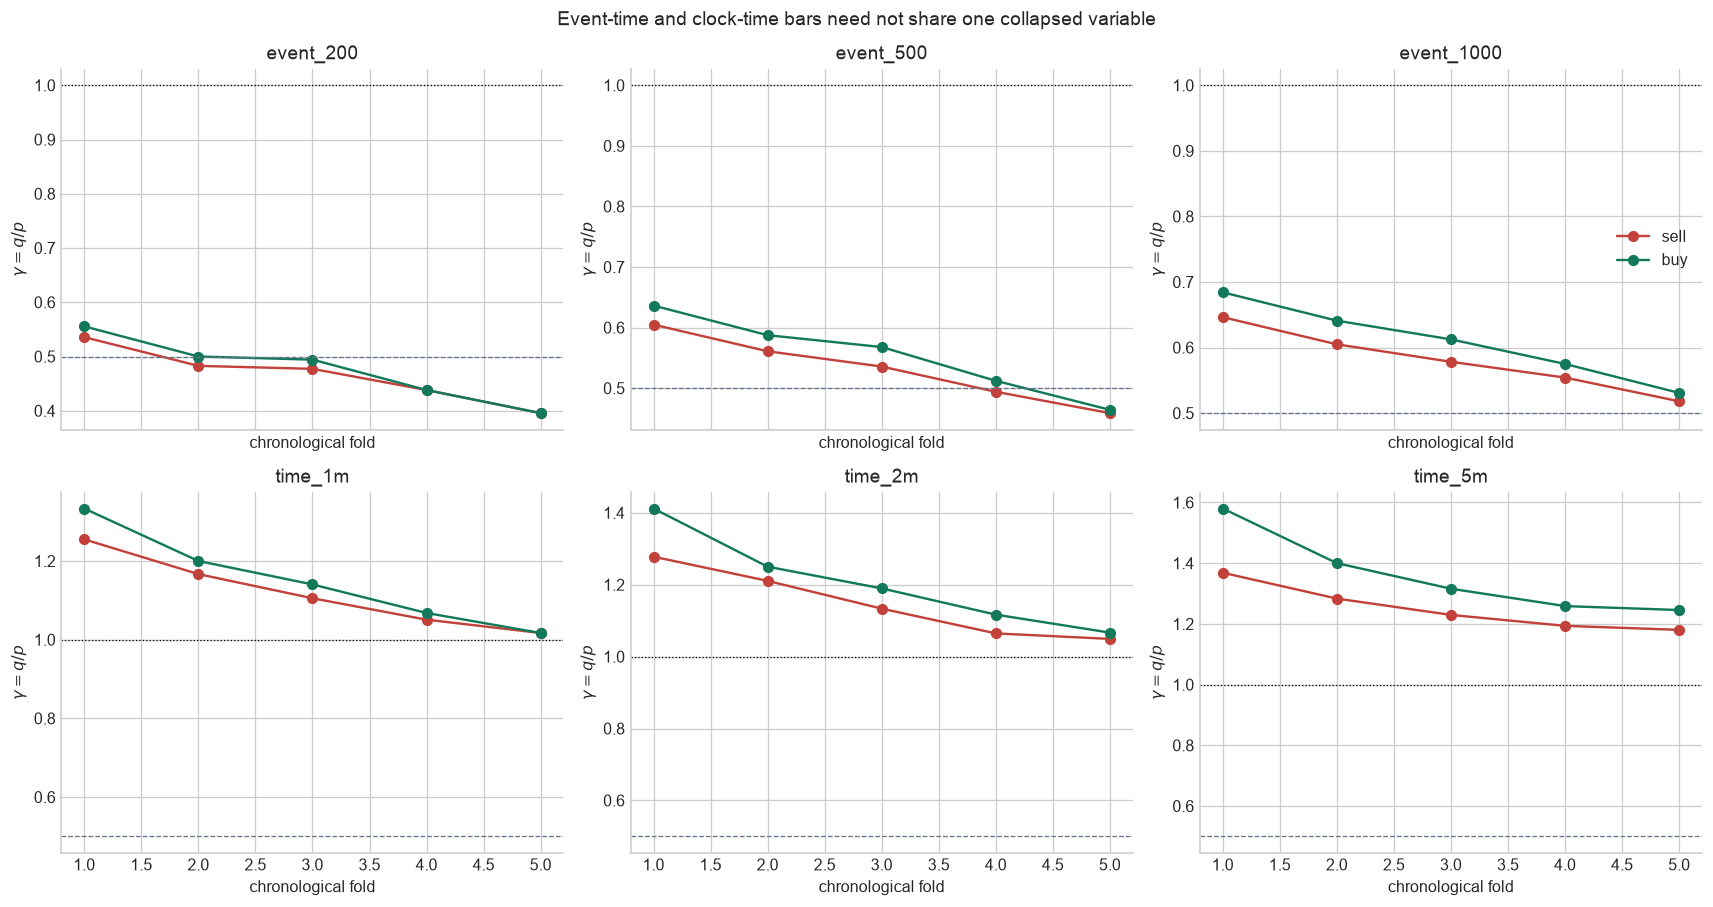

In [6]:
power = fits.filter(pl.col('model') == 'surface_power')
constructions = ['event_200', 'event_500', 'event_1000', 'time_1m', 'time_2m', 'time_5m']
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, construction in zip(axes.flat, constructions):
    for side_name, colour in [('sell', SELL), ('buy', BUY)]:
        part = power.filter(
            (pl.col('construction') == construction) & (pl.col('side') == side_name)
        ).sort('fold')
        ax.plot(part['fold'], part['collapse_exponent_gamma'], 'o-',
                color=colour, label=side_name)
    ax.axhline(0.5, color='#64748b', ls='--', lw=.8)
    ax.axhline(1.0, color='black', ls=':', lw=.8)
    ax.set_title(construction)
    ax.set_xlabel('chronological fold')
    ax.set_ylabel(r'$\gamma=q/p$')
axes[0, 2].legend()
fig.suptitle('Event-time and clock-time bars need not share one collapsed variable')
plt.tight_layout()
plt.show()

# Rolling calibration: window length and model ageing

The five-fold estimates above are expanding fits. The rolling experiment refits the power surface at every month boundary using fixed 6-, 12-, 18-, 24- and 36-month windows plus expanding history. Each frozen fit is then evaluated separately in its first, second and third month of use.

Training-window length and recalibration cadence are different choices. For example, a 12-month window can still be recalibrated every month.

## Rolling parameter path

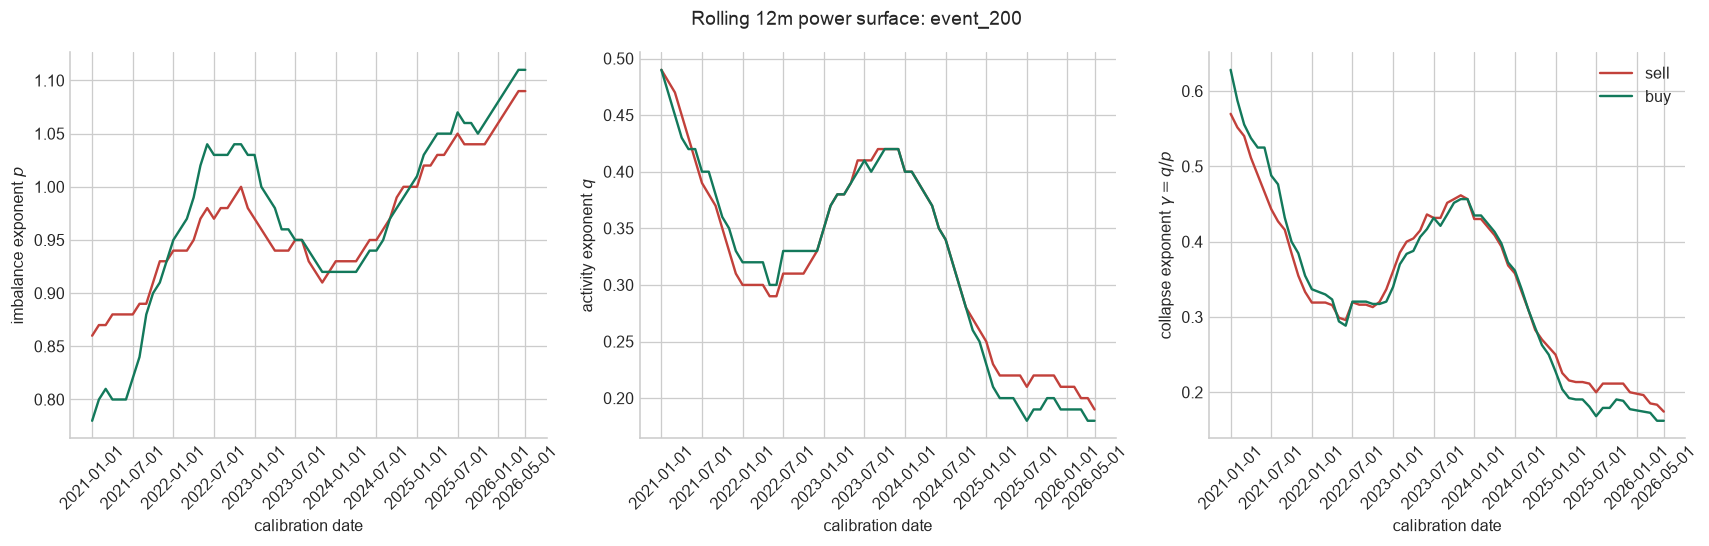

In [7]:
rolling_selected = rolling_fits.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('training_window') == ROLLING_WINDOW)
).sort('calibration_date')
calibration_dates = sorted(rolling_selected['calibration_date'].unique().to_list())
labelled_dates = calibration_dates[::CALIBRATION_DATE_LABEL_EVERY]
if calibration_dates[-1] not in labelled_dates:
    labelled_dates.append(calibration_dates[-1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)
for side_name, colour in [('sell', SELL), ('buy', BUY)]:
    part = rolling_selected.filter(pl.col('side') == side_name)
    axes[0].plot(part['calibration_date'], part['imbalance_exponent_p'],
                 color=colour, label=side_name)
    axes[1].plot(part['calibration_date'], part['activity_exponent_q'],
                 color=colour, label=side_name)
    axes[2].plot(part['calibration_date'], part['collapse_exponent_gamma'],
                 color=colour, label=side_name)
axes[0].set_ylabel(r'imbalance exponent $p$')
axes[1].set_ylabel(r'activity exponent $q$')
axes[2].set_ylabel(r'collapse exponent $\gamma=q/p$')
for ax in axes:
    ax.set_xticks(labelled_dates)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('calibration date')
axes[2].legend()
fig.suptitle(f'Rolling {ROLLING_WINDOW} power surface: {CONSTRUCTION}')
plt.tight_layout()
plt.show()

The rolling path is the appropriate place to diagnose whether the apparently slow expanding-fold drift is genuinely gradual or is an average over sharper regime changes.

## Which training window calibrates best next month?

training_window,mean_test_cell_rmse,median_test_cell_rmse,p90_test_cell_rmse,median_abs_residual_activity_correlation
str,f64,f64,f64,f64
"""6m""",0.000955,0.000939,0.001514,0.034263
"""12m""",0.001056,0.001034,0.001475,0.045563
"""36m""",0.001081,0.001071,0.00145,0.060835
"""18m""",0.001155,0.001117,0.001597,0.05481
"""24m""",0.001156,0.001131,0.001555,0.064832
"""expanding""",0.001274,0.001313,0.001832,0.076448


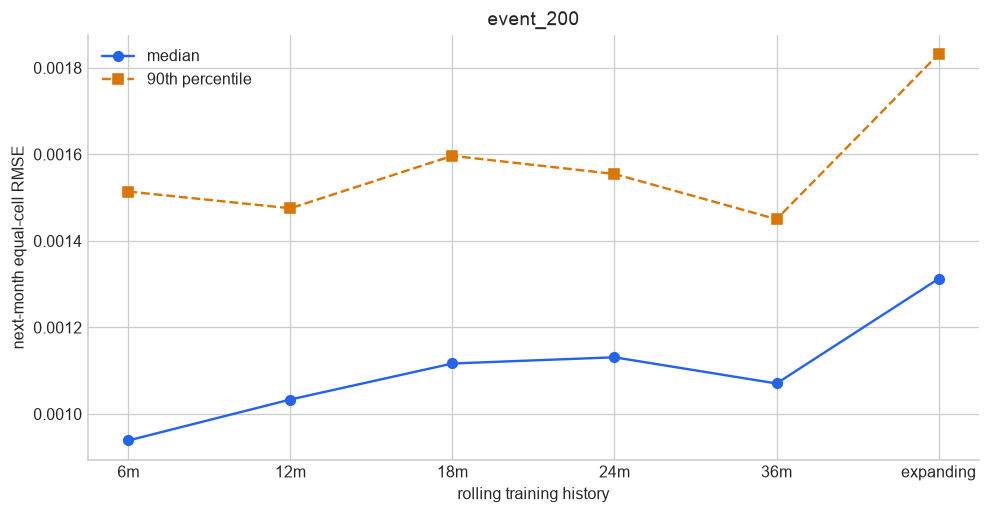

In [8]:
next_month = rolling_calibration.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('calibration_age_months') == 1) &
    (pl.col('calibration_date') >= WINDOW_COMPARISON_START)
)
window_summary = next_month.group_by('training_window').agg(
    pl.col('test_cell_rmse').mean().alias('mean_test_cell_rmse'),
    pl.col('test_cell_rmse').median().alias('median_test_cell_rmse'),
    pl.col('test_cell_rmse').quantile(.90).alias('p90_test_cell_rmse'),
    pl.col('test_residual_log_activity_correlation').abs().median()
      .alias('median_abs_residual_activity_correlation'),
).sort('median_test_cell_rmse')
display(window_summary)

window_order = ['6m', '12m', '18m', '24m', '36m', 'expanding']
lookup = {row['training_window']: row for row in window_summary.iter_rows(named=True)}
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(window_order))
ax.plot(x, [lookup[name]['median_test_cell_rmse'] for name in window_order],
        'o-', color='#2563eb', label='median')
ax.plot(x, [lookup[name]['p90_test_cell_rmse'] for name in window_order],
        's--', color='#d97706', label='90th percentile')
ax.set_xticks(x, window_order)
ax.set_xlabel('rolling training history')
ax.set_ylabel('next-month equal-cell RMSE')
ax.set_title(CONSTRUCTION)
ax.legend()
plt.show()

## How quickly does a frozen calibration age?

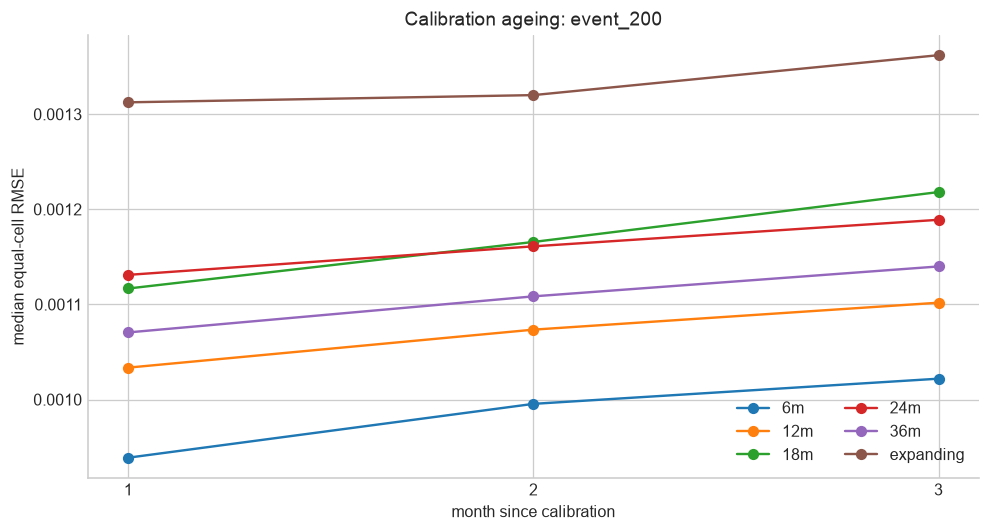

In [9]:
ageing = rolling_calibration.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('calibration_date') >= WINDOW_COMPARISON_START)
).group_by('training_window', 'calibration_age_months').agg(
    pl.col('test_cell_rmse').median().alias('median_test_cell_rmse')
).sort('training_window', 'calibration_age_months')

fig, ax = plt.subplots(figsize=(10, 5))
for window_name in window_order:
    part = ageing.filter(pl.col('training_window') == window_name).sort(
        'calibration_age_months'
    )
    ax.plot(part['calibration_age_months'], part['median_test_cell_rmse'],
            'o-', label=window_name)
ax.set_xticks([1, 2, 3])
ax.set_xlabel('month since calibration')
ax.set_ylabel('median equal-cell RMSE')
ax.set_title(f'Calibration ageing: {CONSTRUCTION}')
ax.legend(ncol=2)
plt.show()

## Operational cadence comparison

recalibration_cadence_months,training_window,mean_test_cell_rmse,mean_side_p90_test_cell_rmse
i64,str,f64,f64
1,"""6m""",0.000955,0.00153
1,"""12m""",0.001056,0.001496
1,"""36m""",0.001081,0.001458
1,"""18m""",0.001155,0.001639
1,"""24m""",0.001156,0.001586
…,…,…,…
3,"""36m""",0.001088,0.001492
3,"""12m""",0.001108,0.001541
3,"""24m""",0.001174,0.001595


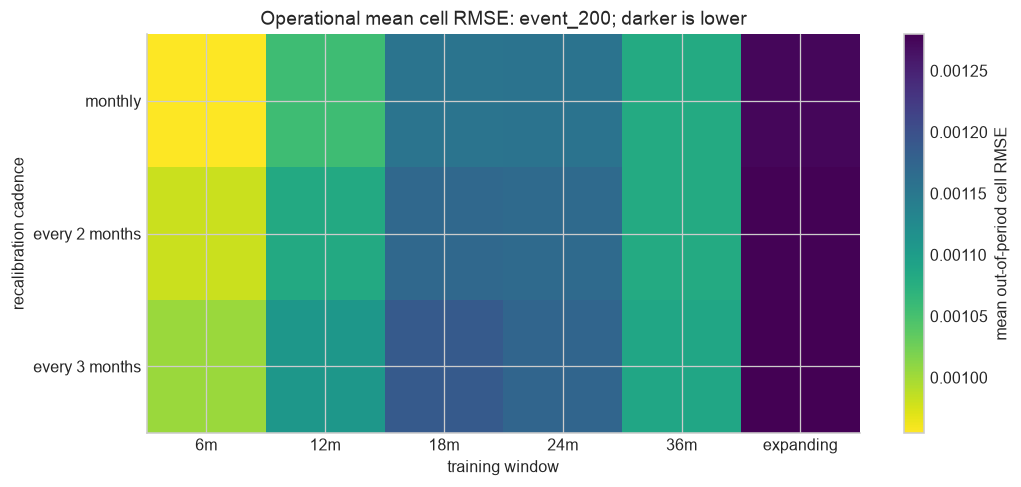

In [10]:
cadence = cadence_summary.filter(pl.col('construction') == CONSTRUCTION).group_by(
    'recalibration_cadence_months', 'training_window'
).agg(
    pl.col('mean_test_cell_rmse').mean().alias('mean_test_cell_rmse'),
    pl.col('p90_test_cell_rmse').mean().alias('mean_side_p90_test_cell_rmse'),
).sort('recalibration_cadence_months', 'mean_test_cell_rmse')
display(cadence)

matrix = np.full((3, len(window_order)), np.nan)
for row in cadence.iter_rows(named=True):
    matrix[row['recalibration_cadence_months'] - 1, window_order.index(row['training_window'])] = row['mean_test_cell_rmse']
fig, ax = plt.subplots(figsize=(10, 4.5))
image = ax.imshow(matrix, aspect='auto', cmap='viridis_r')
ax.set_xticks(np.arange(len(window_order)), window_order)
ax.set_yticks(np.arange(3), ['monthly', 'every 2 months', 'every 3 months'])
ax.set_xlabel('training window')
ax.set_ylabel('recalibration cadence')
ax.set_title(f'Operational mean cell RMSE: {CONSTRUCTION}; darker is lower')
fig.colorbar(image, ax=ax, label='mean out-of-period cell RMSE')
plt.show()

## Formal buy–sell symmetry comparison

specification,median_combined_test_cell_rmse,mean_combined_test_cell_rmse
str,f64,f64
"""separate_shape_and_level""",0.001339,0.001226
"""common_shape_separate_level""",0.001339,0.001222
"""common_shape_and_level""",0.001345,0.001225


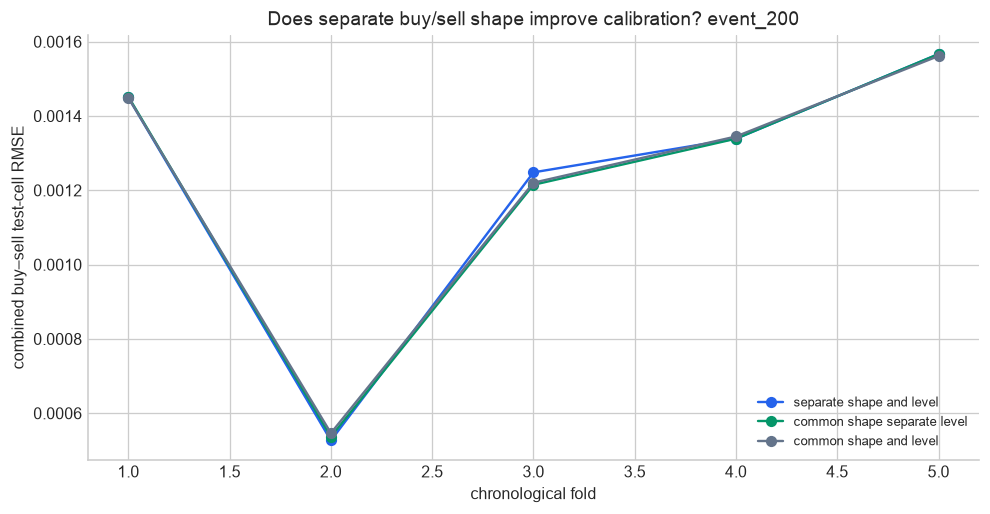

In [11]:
symmetry_selected = symmetry.filter(pl.col('construction') == CONSTRUCTION)
symmetry_summary = symmetry_selected.group_by('specification').agg(
    pl.col('combined_test_cell_rmse').median().alias('median_combined_test_cell_rmse'),
    pl.col('combined_test_cell_rmse').mean().alias('mean_combined_test_cell_rmse'),
).sort('median_combined_test_cell_rmse')
display(symmetry_summary)

fig, ax = plt.subplots(figsize=(10, 4.8))
for specification, colour in [
    ('separate_shape_and_level', '#2563eb'),
    ('common_shape_separate_level', '#059669'),
    ('common_shape_and_level', '#64748b'),
]:
    part = symmetry_selected.filter(
        pl.col('specification') == specification
    ).sort('fold')
    ax.plot(part['fold'], part['combined_test_cell_rmse'], 'o-',
            color=colour, label=specification.replace('_', ' '))
ax.set_xlabel('chronological fold')
ax.set_ylabel('combined buy–sell test-cell RMSE')
ax.set_title(f'Does separate buy/sell shape improve calibration? {CONSTRUCTION}')
ax.legend(fontsize=8)
plt.show()

The symmetry specifications are:

1. separate shape and level: $A_s z^{p_s}a^{q_s}$;
2. common shape, separate level: $A_s z^p a^q$;
3. common shape and level: $A z^p a^q$.

If the restricted lines do not worsen next-period calibration materially, the pooled specification is preferable for frequent recalibration because it estimates fewer moving parameters.

## Out-of-period calibration comparison

model,median_test_cell_rmse,median_test_bar_rmse,median_abs_residual_activity_correlation,fold_side_wins
str,f64,f64,f64,u32
"""surface_power""",0.001332,0.010791,0.077268,10
"""relative_imbalance_power""",0.001664,0.011627,0.167072,0
"""normalised_flow_power""",0.00241,0.010923,0.124892,0
"""normalised_flow_log""",0.002414,0.011072,0.10144,0


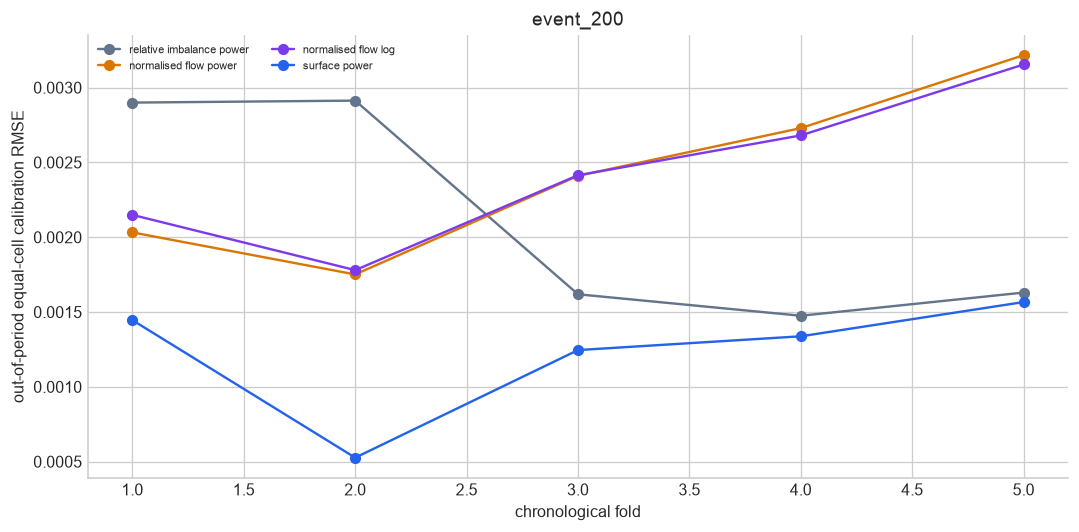

In [12]:
comparison = fits.filter(
    (pl.col('construction') == CONSTRUCTION) &
    pl.col('model').is_in(list(MODEL_COLOURS))
).with_columns(
    pl.col('test_cell_rmse').rank('ordinal').over(['fold', 'side']).alias('rank')
)
display(comparison.group_by('model').agg(
    pl.col('test_cell_rmse').median().alias('median_test_cell_rmse'),
    pl.col('test_bar_rmse').median().alias('median_test_bar_rmse'),
    pl.col('test_residual_log_activity_correlation').abs().median()
      .alias('median_abs_residual_activity_correlation'),
    (pl.col('rank') == 1).sum().alias('fold_side_wins'),
).sort('median_test_cell_rmse'))

fig, ax = plt.subplots(figsize=(11, 5))
for model_name, colour in MODEL_COLOURS.items():
    part = comparison.filter(pl.col('model') == model_name).group_by('fold').agg(
        pl.col('test_cell_rmse').mean().alias('rmse')
    ).sort('fold')
    ax.plot(part['fold'], part['rmse'], 'o-', color=colour,
            label=model_name.replace('_', ' '))
ax.set_xlabel('chronological fold')
ax.set_ylabel('out-of-period equal-cell calibration RMSE')
ax.set_title(CONSTRUCTION)
ax.legend(fontsize=7, ncol=2)
plt.show()

# Residual alpha: information available at the bar close

For each fold, the model and residual-quintile boundaries are fitted only on earlier observations. The future target begins at the current completed bar endpoint:

$$
e_t=y_t-\widehat I_t,\qquad
F_{t,h}=s_t\,10^4\log(P_{t+h}/P_t).
$$

A negative relationship means that unusually positive impact tends to reverse. These are gross-return diagnostics, not profitability estimates.

## Residual IC by model and horizon

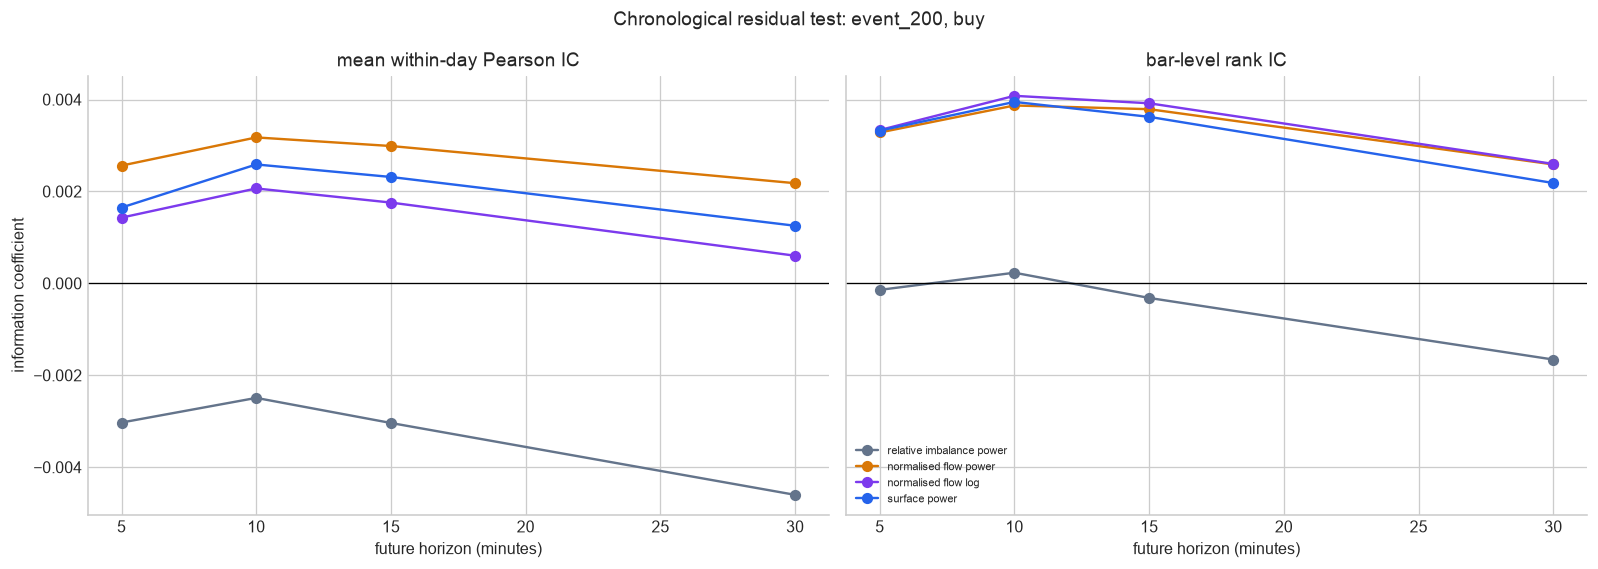

fold,observations,pearson_ic,spearman_ic,day_mean_ic,day_ic_t_stat,day_ic_fdr_bh
i64,i64,f64,f64,f64,f64,f64
1,1305585,-0.000742,0.002079,0.00071,0.472705,0.751487
2,870442,0.002193,0.006043,0.003157,1.520224,0.225689
3,954177,0.002864,0.004757,0.001951,1.191586,0.370514
4,833911,0.001861,0.004536,0.003215,1.758231,0.14804
5,336111,0.00329,0.000703,0.002542,0.852832,0.540598


In [13]:
selected_ic = residual_ic.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('side') == SIDE)
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metric, title in [
    (axes[0], 'day_mean_ic', 'mean within-day Pearson IC'),
    (axes[1], 'spearman_ic', 'bar-level rank IC'),
]:
    for model_name, colour in MODEL_COLOURS.items():
        part = selected_ic.filter(pl.col('model') == model_name).group_by(
            'horizon_minutes'
        ).agg(pl.col(metric).mean().alias(metric)).sort('horizon_minutes')
        ax.plot(part['horizon_minutes'], part[metric], 'o-', color=colour,
                label=model_name.replace('_', ' '))
    ax.axhline(0, color='black', lw=.8)
    ax.set_xlabel('future horizon (minutes)')
    ax.set_title(title)
axes[0].set_ylabel('information coefficient')
axes[1].legend(fontsize=7)
fig.suptitle(f'Chronological residual test: {CONSTRUCTION}, {SIDE}')
plt.tight_layout()
plt.show()

display(selected_ic.filter(
    (pl.col('model') == MODEL) &
    (pl.col('horizon_minutes') == HORIZON_MINUTES)
).select('fold', 'observations', 'pearson_ic', 'spearman_ic', 'day_mean_ic',
         'day_ic_t_stat', 'day_ic_fdr_bh').sort('fold'))

## Residual quintile response curve

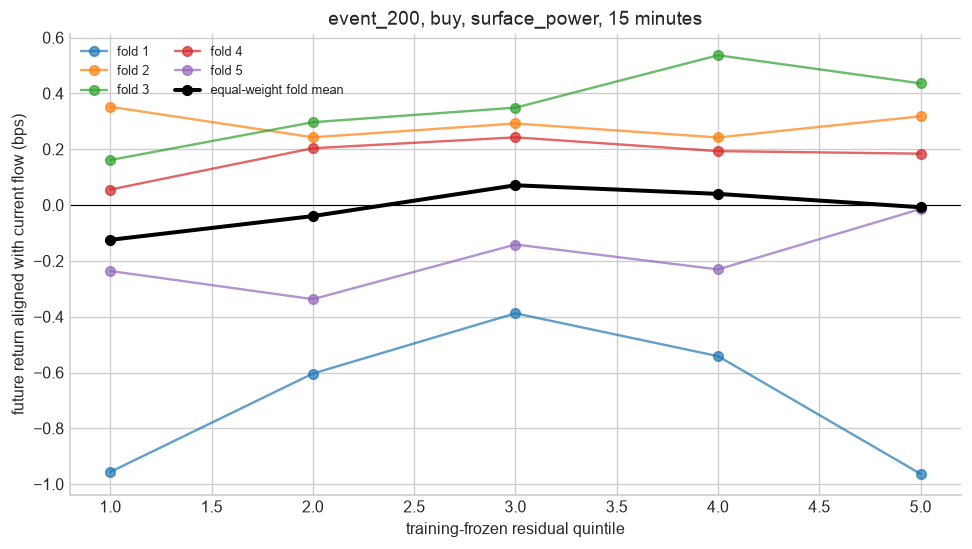

In [14]:
curves = residual_quantiles.filter(
    (pl.col('construction') == CONSTRUCTION) &
    (pl.col('side') == SIDE) &
    (pl.col('model') == MODEL) &
    (pl.col('horizon_minutes') == HORIZON_MINUTES)
)
fig, ax = plt.subplots(figsize=(10, 5.2))
for fold in sorted(curves['fold'].unique()):
    part = curves.filter(pl.col('fold') == fold).sort('residual_quantile')
    ax.plot(part['residual_quantile'], part['day_mean_bps'], 'o-', alpha=.7,
            label=f'fold {fold}')
mean_curve = curves.group_by('residual_quantile').agg(
    pl.col('day_mean_bps').mean().alias('mean')
).sort('residual_quantile')
ax.plot(mean_curve['residual_quantile'], mean_curve['mean'], 'o-', color='black',
        lw=2.5, label='equal-weight fold mean')
ax.axhline(0, color='black', lw=.7)
ax.set_xlabel('training-frozen residual quintile')
ax.set_ylabel('future return aligned with current flow (bps)')
ax.set_title(f'{CONSTRUCTION}, {SIDE}, {MODEL}, {HORIZON_MINUTES} minutes')
ax.legend(ncol=2, fontsize=8)
plt.show()

## High-residual reversion as an initial gross signal

In [15]:
strategy = residual_strategies.filter(
    (pl.col('strategy') == 'high_residual_reversion') &
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    pl.col('model').is_in(list(MODEL_COLOURS))
)
summary = strategy.group_by('construction', 'model').agg(
    pl.col('day_mean_bps').mean().alias('mean_day_return_bps'),
    pl.col('day_mean_bps').median().alias('median_day_return_bps'),
    (pl.col('day_mean_bps') > 0).sum().alias('positive_fold_side_cells'),
    pl.len().alias('fold_side_cells'),
    pl.col('day_t_stat').median().alias('median_day_t_stat'),
).sort('construction', 'mean_day_return_bps', descending=[False, True])
display(summary)

construction,model,mean_day_return_bps,median_day_return_bps,positive_fold_side_cells,fold_side_cells,median_day_t_stat
str,str,f64,f64,u32,u32,f64
"""event_1000""","""relative_imbalance_power""",0.748423,0.553646,9,10,0.990538
"""event_1000""","""normalised_flow_log""",0.583661,0.446755,8,10,0.929112
"""event_1000""","""normalised_flow_power""",0.562097,0.40023,8,10,0.851773
"""event_1000""","""surface_power""",0.535189,0.394285,8,10,0.791177
"""event_200""","""relative_imbalance_power""",0.293521,0.158832,6,10,0.278942
…,…,…,…,…,…,…
"""time_2m""","""surface_power""",0.482091,0.474386,10,10,1.576058
"""time_5m""","""relative_imbalance_power""",1.11012,1.065182,10,10,2.471974
"""time_5m""","""normalised_flow_log""",0.708307,0.762263,10,10,1.670229


## Physical interpretation and next gate

The power surface corresponds to a coarse liquidity model:

$$
\frac{\Delta p}{\sigma}\approx \frac{Q^{net}}{L_{eff}/V_{24h}},
\qquad
L_{eff}\propto V_{24h}a^{1-q}.
$$

For event bars, $q$ around one-half says that effective liquidity expands with activity but not one-for-one. The next physical tests should condition the initial shock on first-to-last event-price sweep and estimate the subsequent resilience kernel. A positive residual followed by a negative aligned future return is then interpreted as temporary overshoot; continuation instead suggests information or delayed permanent impact.

Before treating the residual as a strategy, require:

1. stable sign across folds and both sides;
2. robustness across credible rolling-window and symmetry specifications;
3. robustness to pretrend and volatility controls;
4. an explicit spread, fee, slippage, latency and overlapping-position simulation;
5. no access to June–August 2026 until the rule is frozen.